# Initialize

In [1]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import matplotlib.pyplot as plt
import time
import numpy as np

LOG.propagate = False

In [2]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()
ble.reload_config()

2026-04-26 17:29:26,611 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:0c:78:b8:49
2026-04-26 17:29:26,611 | INFO     |: Scanning for device with address: c0:42:0c:78:b8:49, service UUID: d427e7cc-c400-4597-b417-d564e20d6600


2026-04-26 17:29:36,683 | INFO     |: Found 1 device(s) advertising service d427e7cc-c400-4597-b417-d564e20d6600
2026-04-26 17:29:36,684 | INFO     |: Selecting device: 3AE32BFA-4071-EC2D-ED7A-60CCA92DBE18 (name: Artemis BLE)
2026-04-26 17:29:37,710 | INFO     |: Connected to c0:42:0c:78:b8:49


In [7]:
times = []
yaw_values = []
tof_1_values = []
tof_2_values = []

def log_handler(sender, data: bytearray):
    parts = ble.bytearray_to_string(data).split("|")
    if len(parts) == 4:
        timestamp = float(parts[0][2:])
        yaw = float(parts[1][3:])
        tof_1 = float(parts[2][3:])
        tof_2 = float(parts[3][3:])
        times.append(timestamp)
        yaw_values.append(yaw)
        tof_1_values.append(tof_1)
        tof_2_values.append(tof_2)
        
        print (f"t: {timestamp:.2f}, yaw: {yaw:.2f}, tof_1: {tof_1:.2f}, tof_2: {tof_2:.2f}")
    else:
        print(ble.bytearray_to_string(data))


ble.send_command(CMD.SET_MODE, "3")
ble.send_command(CMD.SET_DURATION, "15000")
ble.send_command(CMD.SET_MOTOR_SCALE, "1.0")

# ble.send_command(CMD.SET_ORIENT_SETPOINT, "0")
ble.send_command(CMD.SET_MAP_DEGREES, "180")
ble.send_command(CMD.UPDATE_ORIENT_PID, "2.5|1.2|0.25")
ble.send_command(CMD.SET_SAMPLE_RATE, "10")

In [12]:
ble.start_notify(ble.uuid["RX_STRING"], log_handler)

In [13]:
times = []
yaw_values = []
tof_1_values = []
tof_2_values = []
ble.send_command(CMD.START_RECORD, "")
time.sleep(5)
ble.send_command(CMD.SEND_LOG, "")

Sample Count: 47| ToF1 Count: 49| ToF2 Count: 48| IMU Count: 283| Dist PID Count: 0| Orient PID Count: 0


In [790]:
times = []
left_motors = []
right_motors = []
acc_x_values = []
# acc_y_values = []
gyr_z_values = []
yaw_values = []
# tof_1_values = []
# tof_2_values = []
orient_setpoint_values = []
orient_sensor_values = []
orient_output_values = []
orient_error_values = []
orient_integral_values = []
orient_derivative_values = []


def log_handler(sender, data: bytearray):
    parts = ble.bytearray_to_string(data).split("|")
    if len(parts) == 12:
        t = float(parts[0][2:])
        l = float(parts[1][5:])
        r = float(parts[2][5:])
        ax = float(parts[3][3:])
        # ay = float(parts[4][3:])
        gz = float(parts[4][3:])
        yw = float(parts[5][3:])
        # t1 = float(parts[6][3:])
        # t2 = float(parts[7][3:])
        os = float(parts[6][3:])
        ov = float(parts[7][3:])
        oo = float(parts[8][3:])
        oe = float(parts[9][3:])
        oi = float(parts[10][3:])
        od = float(parts[11][3:])
        times.append(t) # Convert microseconds to seconds
        left_motors.append(l)
        right_motors.append(r)
        acc_x_values.append(ax)
        # acc_y_values.append(ay)
        gyr_z_values.append(gz)
        yaw_values.append(yw)
        # tof_1_values.append(t1)
        # tof_2_values.append(t2)
        orient_setpoint_values.append(os)
        orient_output_values.append(ov)
        orient_sensor_values.append(oo)
        orient_error_values.append(oe)
        orient_integral_values.append(oi)
        orient_derivative_values.append(od)

        print (f"t: {t:.2f}, lm: {l:.2f}, rm: {r:.2f}, ax: {ax:.2f},  gz: {gz:.2f}, yw: {yw:.2f}, os: {os:.2f}, ov: {ov:.2f}, oo: {oo:.2f}, oe: {oe:.2f}, oi: {oi:.2f}, od: {od:.2f}")
    else:
        print(ble.bytearray_to_string(data))

In [791]:
ble.start_notify(ble.uuid["RX_STRING"], log_handler)

# PID

In [794]:
ble.send_command(CMD.SET_MODE, "5")
ble.send_command(CMD.SET_DURATION, "25000")
ble.send_command(CMD.SET_MOTOR_SCALE, "1.0")

# ble.send_command(CMD.SET_ORIENT_SETPOINT, "0")
ble.send_command(CMD.SET_MAP_DEGREES, "360")
ble.send_command(CMD.UPDATE_ORIENT_PID, "2.5|1.2|0.25")
ble.send_command(CMD.SET_SAMPLE_RATE, "50")

In [ ]:
times = []
left_motors = []
right_motors = []
acc_x_values = []
# acc_y_values = []
gyr_z_values = []
yaw_values = []
# tof_1_values = []
# tof_2_values = []
orient_setpoint_values = []
orient_sensor_values = []
orient_output_values = []
orient_error_values = []
orient_integral_values = []
orient_derivative_values = []

ble.send_command(CMD.START_RECORD, "")
time.sleep(30)
ble.send_command(CMD.SEND_LOG, "")

t: 28.00, lm: 100.00, rm: -150.00, ax: 38.33,  gz: 0.12, yw: 15.00, os: 20.00, ov: -0.00, oo: -50.43, oe: -20.00, oi: -0.36, od: -0.00
t: 50.00, lm: 101.00, rm: -151.00, ax: 38.33,  gz: 0.12, yw: 15.00, os: 20.00, ov: 0.00, oo: -50.71, oe: -20.00, oi: -0.59, od: 0.00
t: 77.00, lm: 98.00, rm: -149.00, ax: 343.99,  gz: 19.88, yw: 15.35, os: 20.00, ov: 0.35, oo: -49.95, oe: -19.65, oi: -1.26, od: 2.76
t: 110.00, lm: 93.00, rm: -142.00, ax: -37.60,  gz: 21.77, yw: 16.13, os: 20.00, ov: 1.13, oo: -46.32, oe: -18.87, oi: -1.79, od: 12.03
t: 148.00, lm: 94.00, rm: -142.00, ax: 37.35,  gz: 6.77, yw: 16.47, os: 20.00, ov: 1.47, oo: -46.53, oe: -18.53, oi: -2.45, od: 10.99
t: 187.00, lm: 98.00, rm: -149.00, ax: -39.79,  gz: -18.17, yw: 16.17, os: 20.00, ov: 1.17, oo: -49.88, oe: -18.83, oi: -3.19, od: 4.08
t: 213.00, lm: 96.00, rm: -146.00, ax: -107.42,  gz: 14.15, yw: 16.66, os: 20.00, ov: 1.65, oo: -48.49, oe: -18.35, oi: -3.81, od: 7.80
t: 236.00, lm: 95.00, rm: -145.00, ax: 194.09,  gz: 6.10

In [786]:
times = np.array(times)
left_motors = np.array(left_motors)
right_motors = np.array(right_motors)
acc_x_values = np.array(acc_x_values)
# acc_y_values = np.array(acc_y_values)
acc_y_values = np.zeros_like(acc_x_values)
gyr_z_values = np.array(gyr_z_values)
yaw_values = np.array(yaw_values)
# tof_1_values = np.array(tof_1_values)
# tof_2_values = np.array(tof_2_values)
orient_setpoint_values = np.array(orient_setpoint_values)
orient_sensor_values = np.array(orient_sensor_values)
orient_output_values = np.array(orient_output_values)
orient_error_values = np.array(orient_error_values)
orient_integral_values = np.array(orient_integral_values)
orient_derivative_values = np.array(orient_derivative_values)

In [787]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ==========================================
# 1. 修复角度数据：将 Wrapped Yaw 解包为 Continuous Yaw
# ==========================================
times_sec = times / 1000.0

yaw_unwrapped = np.degrees(np.unwrap(np.radians(yaw_values)))
yaw_continuous = yaw_unwrapped - yaw_unwrapped[0]
orient_setpoint_continuous = orient_setpoint_values
orient_setpoint_continuous[0] = yaw_continuous[0]

# ==========================================
# 2. PID
# ==========================================
kp = 2.5
ki = 1.2
kd = 0.3
setpoint = 0.0
p_term = -kp * orient_error_values
d_term = -kd * orient_derivative_values
i_term = -ki * orient_integral_values

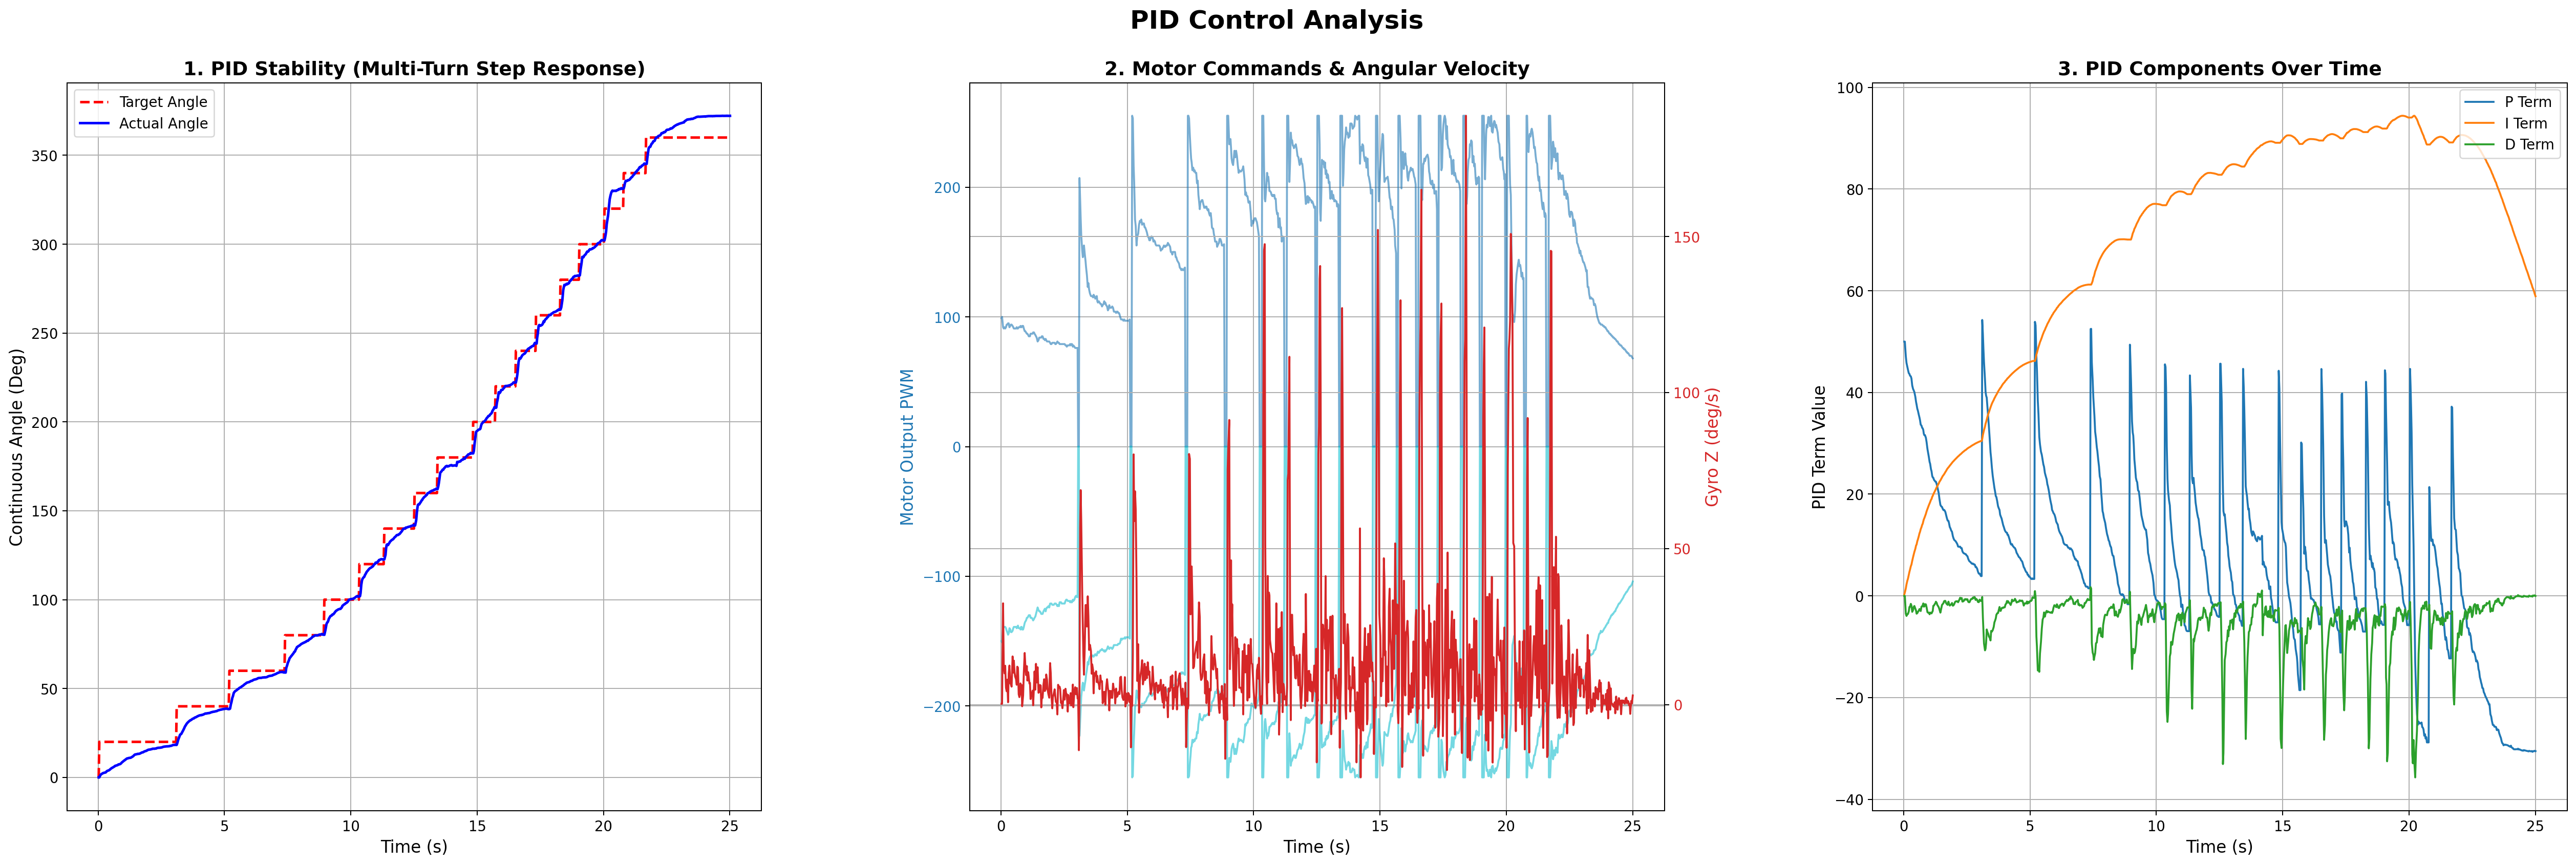

In [788]:
# ==========================================
# 开始绘图
# ==========================================
plt.rcParams['figure.dpi'] = 180      # notebook / 屏幕显示清晰度
plt.rcParams['savefig.dpi'] = 300     # 保存图片清晰度
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

fig = plt.figure(figsize=(35, 10))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.3, hspace=0.3)

# ------------------------------------------
# [1] 左上: PID 角度控制分析
# ------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(times_sec, orient_setpoint_continuous, label='Target Angle', linestyle='--', color='red', linewidth=2)
ax1.plot(times_sec, yaw_continuous, label='Actual Angle', color='blue', linewidth=2)
ax1.set_title('1. PID Stability (Multi-Turn Step Response)', fontweight='bold')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Continuous Angle (Deg)')
ax1.grid(True)
ax1.legend()
# ax1.set_xlim(5, 6)
# ax1.set_ylim(0, 100)

# ------------------------------------------
# [2] 中上: 电机输出与角速度响应
# ------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(times_sec, left_motors, label='Left PWM', color='tab:blue', alpha=0.6)
ax2.plot(times_sec, right_motors, label='Right PWM', color='tab:cyan', alpha=0.6)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Motor Output PWM', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.grid(True)

ax2_twin = ax2.twinx()
ax2_twin.plot(times_sec, gyr_z_values, label='Gyro Z', color='tab:red', linewidth=1.5)
ax2_twin.set_ylabel('Gyro Z (deg/s)', color='tab:red')
ax2_twin.tick_params(axis='y', labelcolor='tab:red')
ax2.set_title('2. Motor Commands & Angular Velocity', fontweight='bold')
# ax2.set_xlim(5, 10)
# ax2_twin.set_ylim(-40, 40)

# ------------------------------------------
# [3] 右上: PID 各项分析
# ------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(times_sec, p_term, label='P Term', color='tab:blue', linewidth=1.5)
ax3.plot(times_sec, i_term, label='I Term', color='tab:orange', linewidth=1.5)
ax3.plot(times_sec, d_term, label='D Term', color='tab:green', linewidth=1.5)
ax3.set_title('3. PID Components Over Time', fontweight='bold')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('PID Term Value')
ax3.grid(True)
ax3.legend(loc='upper right')


fig.suptitle('PID Control Analysis', fontsize=20, fontweight='bold', y=0.98)
fig.subplots_adjust(top=0.90) 
plt.show()

# Control

In [ ]:
ble.send_command(CMD.SET_MODE, "5")
ble.send_command(CMD.SET_DURATION, "60000")
ble.send_command(CMD.SET_MOTOR_SCALE, "1.0")

# ble.send_command(CMD.SET_ORIENT_SETPOINT, "0")
ble.send_command(CMD.SET_MAP_DEGREES, "360")
ble.send_command(CMD.UPDATE_ORIENT_PID, "2.5|1.2|0.25")
ble.send_command(CMD.SET_SAMPLE_RATE, "50")

In [653]:
times = []
left_motors = []
right_motors = []
acc_x_values = []
# acc_y_values = []
gyr_z_values = []
yaw_values = []
tof_1_values = []
tof_2_values = []
orient_setpoint_values = []
orient_sensor_values = []
orient_output_values = []

ble.send_command(CMD.START_RECORD, "")
time.sleep(65)
ble.send_command(CMD.SEND_LOG, "")

Exception: Not connected to a BLE device

In [644]:
times = np.array(times)
left_motors = np.array(left_motors)
right_motors = np.array(right_motors)
acc_x_values = np.array(acc_x_values)
# acc_y_values = np.array(acc_y_values)
acc_y_values = np.zeros_like(acc_x_values)
gyr_z_values = np.array(gyr_z_values)
yaw_values = np.array(yaw_values)
tof_1_values = np.array(tof_1_values)
tof_2_values = np.array(tof_2_values)
orient_setpoint_values = np.array(orient_setpoint_values)
orient_sensor_values = np.array(orient_sensor_values)
orient_output_values = np.array(orient_output_values)



In [767]:
# np.savez("lab9/map_5_3_1080.npz", 
#     times=times, 
#     left_motors=left_motors, 
#     right_motors=right_motors, 
#     acc_x_values=acc_x_values, 
#     # acc_y_values=acc_y_values, 
#     gyr_z_values=gyr_z_values, 
#     yaw_values=yaw_values,
#     tof_1_values=tof_1_values,
#     tof_2_values=tof_2_values, 
#     orient_setpoint_values=orient_setpoint_values, 
#     orient_sensor_values=orient_sensor_values, 
#     orient_output_values=orient_output_values
# )

In [769]:
data = np.load("lab9/map_5_3_1080.npz")
times = data["times"]
left_motors = data["left_motors"]
right_motors = data["right_motors"]
acc_x_values = data["acc_x_values"]
# acc_y_values = data["acc_y_values"]
gyr_z_values = data["gyr_z_values"]
yaw_values = data["yaw_values"]
tof_1_values = data["tof_1_values"]
tof_2_values = data["tof_2_values"]
orient_setpoint_values = data["orient_setpoint_values"]
orient_sensor_values = data["orient_sensor_values"]
orient_output_values = data["orient_output_values"]

# tof_1_values = np.zeros_like(tof_2_values)
acc_y_values = np.zeros_like(acc_x_values)
# tof_1_values = tof_1_values + 31.75
# tof_2_values  = tof_2_values + 69.85

In [770]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ==========================================
# 1. 修复角度数据：将 Wrapped Yaw 解包为 Continuous Yaw
# ==========================================
times_sec = times / 1000.0

yaw_unwrapped = np.degrees(np.unwrap(np.radians(yaw_values)))
yaw_continuous = yaw_unwrapped - yaw_unwrapped[0]
orient_setpoint_continuous = orient_setpoint_values
orient_setpoint_continuous[0] = yaw_continuous[0]

# ==========================================
# 2. 核心计算：加速度 -> 局部速度 -> 世界速度 -> 世界位移
# ==========================================


STOP_THRESHOLD_GYRO = 12
stationary_mask = np.abs(gyr_z_values) < STOP_THRESHOLD_GYRO
acc_x_bias = np.mean(acc_x_values[stationary_mask])
acc_y_bias = np.mean(acc_y_values[stationary_mask])

acc_x_clean = acc_x_values- acc_x_bias
acc_y_clean = np.zeros_like(acc_y_values, dtype=float) 
acc_y_clean = acc_y_values- acc_y_bias

vel_local_x = np.zeros_like(acc_x_values, dtype=float)
vel_local_y = np.zeros_like(acc_y_values, dtype=float)
vel_world_x = np.zeros_like(acc_x_values, dtype=float)
vel_world_y = np.zeros_like(acc_y_values, dtype=float)
disp_world_x = np.zeros_like(acc_x_values, dtype=float)
disp_world_y = np.zeros_like(acc_y_values, dtype=float)

ACC_SCALE = 9.81 / 1000.0
VELOCITY_DAMPING = 1

for i in range(1, len(times)):
    dt = (times[i] - times[i - 1]) / 1000.0
    if dt <= 0:
        continue

    # local acceleration -> local velocity
    vel_local_x[i] = vel_local_x[i - 1]  + acc_x_clean[i] * ACC_SCALE * dt * 0.9
    vel_local_y[i] = vel_local_y[i - 1]  + acc_y_clean[i] * ACC_SCALE * dt

    # ZUPT
    if stationary_mask[i]:
        vel_local_x[i] = 0.0
        vel_local_y[i] = 0.0

    # yaw sign may need flip
    theta = -np.radians(yaw_continuous[i])

    # rotate local velocity -> world velocity
    vel_world_x[i] = vel_local_x[i] * np.cos(theta) - vel_local_y[i] * np.sin(theta)
    vel_world_y[i] = vel_local_x[i] * np.sin(theta) + vel_local_y[i] * np.cos(theta)

    # integrate world velocity -> world displacement
    disp_world_x[i] = disp_world_x[i - 1] + vel_world_x[i] * dt
    disp_world_y[i] = disp_world_y[i - 1] + vel_world_y[i] * dt

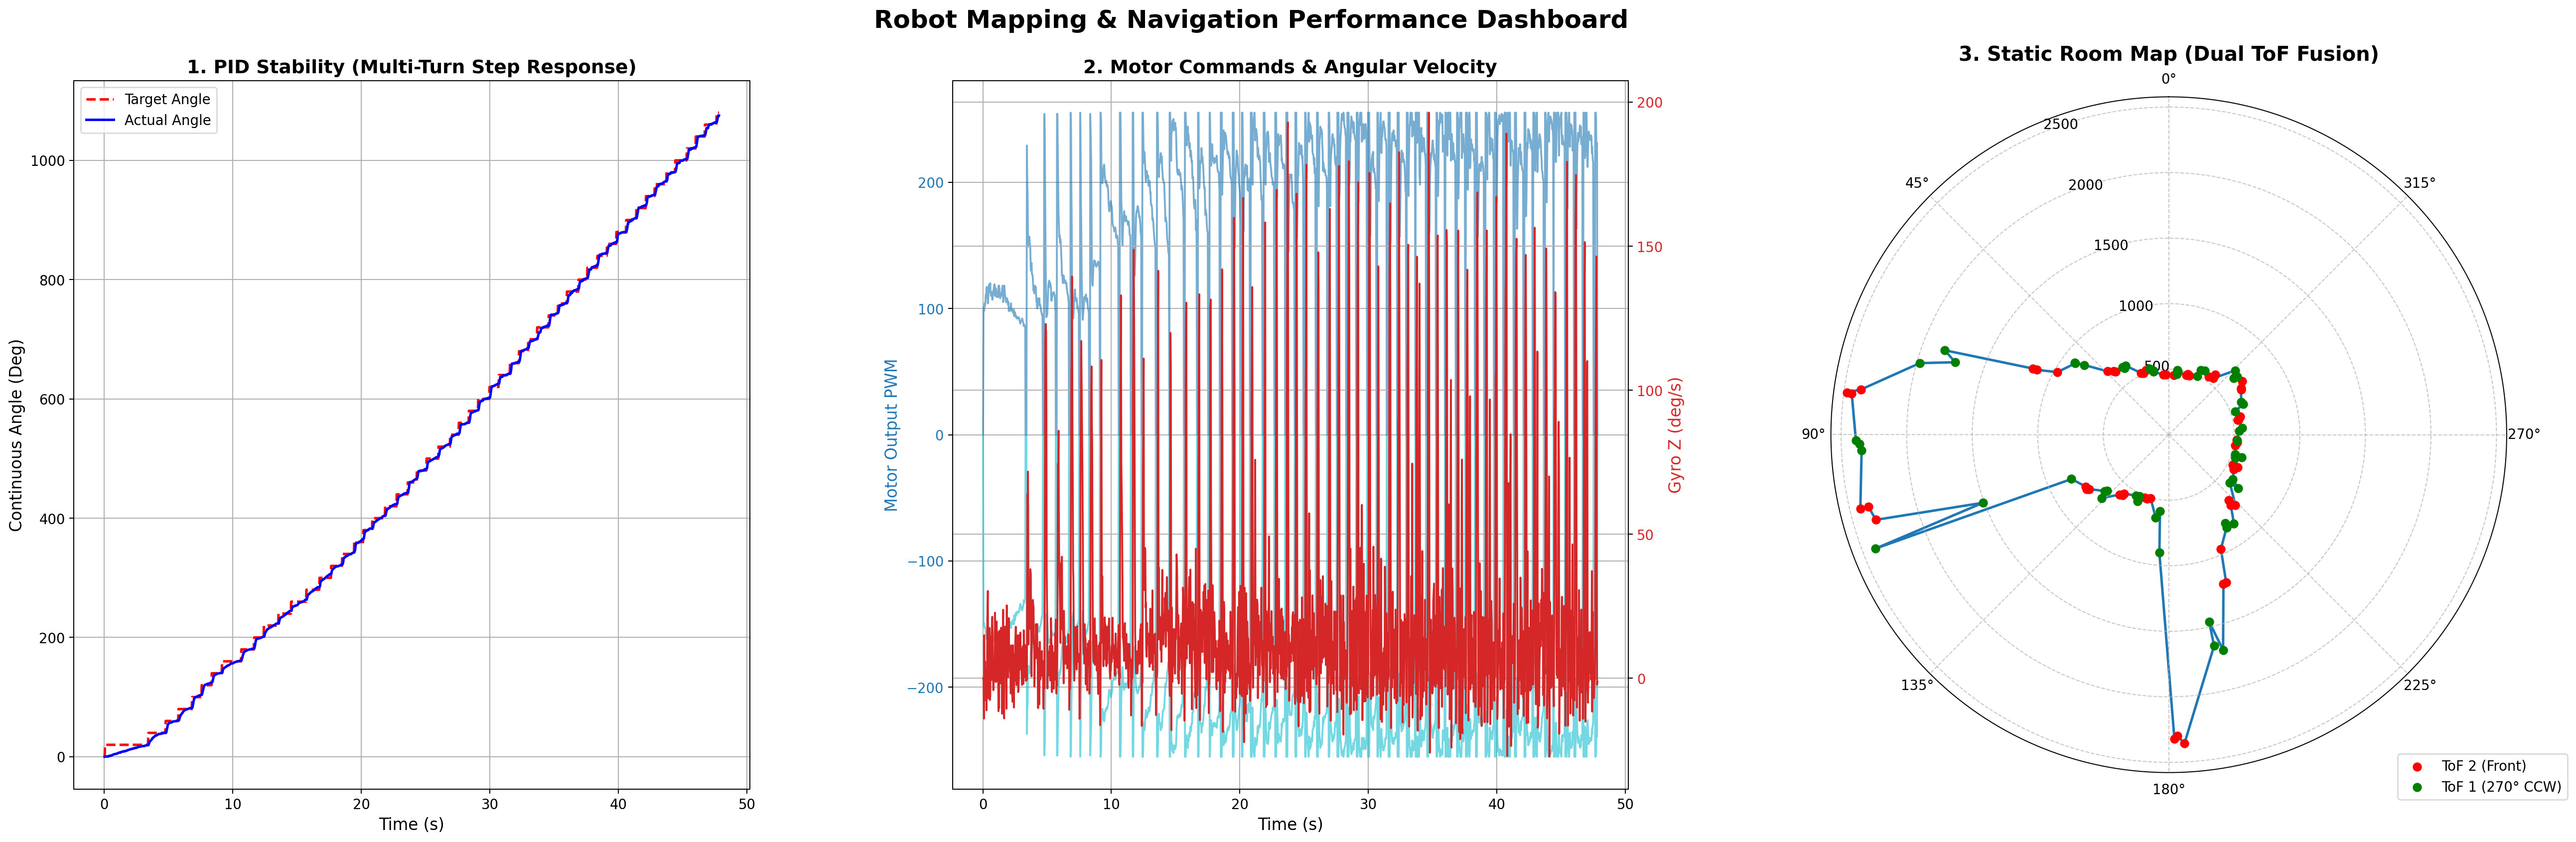

=== Mapping Summary ===
Total valid points (ToF1 + ToF2): 108
Max line of sight:  2476.85 mm
Closest wall dist:  455.85 mm

=== Drift Summary ===
Final X Drift:      92.59 mm
Final Y Drift:      -415.33 mm
Total Center Shift: 425.52 mm


In [771]:
# ==========================================
# 开始绘图
# ==========================================
plt.rcParams['figure.dpi'] = 180      # notebook / 屏幕显示清晰度
plt.rcParams['savefig.dpi'] = 300     # 保存图片清晰度
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

fig = plt.figure(figsize=(35, 10))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.3, hspace=0.3)

# ------------------------------------------
# [1] 左上: PID 角度控制分析
# ------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(times_sec, orient_setpoint_continuous, label='Target Angle', linestyle='--', color='red', linewidth=2)
ax1.plot(times_sec, yaw_continuous, label='Actual Angle', color='blue', linewidth=2)
ax1.set_title('1. PID Stability (Multi-Turn Step Response)', fontweight='bold')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Continuous Angle (Deg)')
ax1.grid(True)
ax1.legend()
# ax1.set_xlim(5, 6)
# ax1.set_ylim(0, 100)

# ------------------------------------------
# [2] 中上: 电机输出与角速度响应
# ------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(times_sec, left_motors, label='Left PWM', color='tab:blue', alpha=0.6)
ax2.plot(times_sec, right_motors, label='Right PWM', color='tab:cyan', alpha=0.6)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Motor Output PWM', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.grid(True)

ax2_twin = ax2.twinx()
ax2_twin.plot(times_sec, gyr_z_values, label='Gyro Z', color='tab:red', linewidth=1.5)
ax2_twin.set_ylabel('Gyro Z (deg/s)', color='tab:red')
ax2_twin.tick_params(axis='y', labelcolor='tab:red')
ax2.set_title('2. Motor Commands & Angular Velocity', fontweight='bold')
# ax2.set_xlim(5, 10)
# ax2_twin.set_ylim(-40, 40)

# # ------------------------------------------
# # [3] 左下: 原地旋转可靠性 (速度与世界位移)
# # ------------------------------------------
# ax3 = fig.add_subplot(gs[1, 0])
# ax3.plot(times_sec, vel_world_x, label='World Vel X', color='orange', alpha=0.7)
# ax3.plot(times_sec, vel_world_y, label='World Vel Y', color='green', alpha=0.7)
# ax3.set_xlabel('Time (s)')
# ax3.set_ylabel('World Velocity (m/s)')
# ax3.grid(True)
# ax3.legend(loc='upper left', fontsize=9)

# ax3_twin = ax3.twinx()
# ax3_twin.plot(times_sec, disp_world_x, label='World Disp X', color='red', linestyle='-.', linewidth=2)
# ax3_twin.plot(times_sec, disp_world_y, label='World Disp Y', color='purple', linestyle='-.', linewidth=2)
# ax3_twin.set_ylabel('Accumulated Disp (m)')
# ax3_twin.legend(loc='lower right', fontsize=9)
# ax3.set_title('3. On-Axis Reliability (Vel & Disp)', fontweight='bold')

# # ------------------------------------------
# # [4] 中下: 机器人在地面的 2D 纯漂移轨迹
# # ------------------------------------------
# ax4 = fig.add_subplot(gs[1, 1])
# ax4.plot(disp_world_x, disp_world_y, label='Drift Path', color='blue')
# ax4.scatter(disp_world_x[0], disp_world_y[0], color='green', marker='o', s=100, label='Start (0,0)', zorder=5)
# ax4.scatter(disp_world_x[-1], disp_world_y[-1], color='red', marker='x', s=100, label='End', zorder=5)
# ax4.set_title('4. Robot Center Drift Trajectory (2D)', fontweight='bold')
# ax4.set_xlabel('World X Displacement (m)')
# ax4.set_ylabel('World Y Displacement (m)')
# ax4.axis('equal') # 保证 X Y 比例一致，圆形不会被拉伸成椭圆
# ax4.grid(True, linestyle='--')
# ax4.legend()
# ax4.set_xlim(-0.25, 0.25)
# ax4.set_ylim(-0.25, 0.25)

# ------------------------------------------
# [5] 右侧一整列: 极坐标房间建图 (跨两行)
# ------------------------------------------
# === ToF 2 (正前方) 数据 ===
valid_indices_2 = (tof_2_values > 0) & (tof_2_values < 6000)
valid_angles_rad_2 = np.radians(yaw_continuous[valid_indices_2])
valid_distances_2 = tof_2_values[valid_indices_2] + 69.85

# === ToF 1 (逆时针 270 度 / 正右侧) 数据 ===
valid_indices_1 = (tof_1_values > 0) & (tof_1_values < 6000)
# 核心计算：物理角度 = 机器人朝向角 + 270度
valid_angles_rad_1 = np.radians(yaw_continuous[valid_indices_1] + 270.0)
valid_distances_1 = tof_1_values[valid_indices_1] + 31.75

# 合并两个传感器的点云数据
all_angles = np.concatenate([valid_angles_rad_2, valid_angles_rad_1])
all_distances = np.concatenate([valid_distances_2, valid_distances_1])

if len(all_distances) > 0:
    # 🌟 关键修复：将所有角度统一 Wrap 到 0~2pi 范围内！
    # 否则 argsort 会把 tof1(含有>360度的角) 和 tof2 分离，导致画出螺旋线
    all_angles_wrapped = all_angles % (2 * np.pi)
    
    # 按照绝对角度大小排序，以绘制连续的墙壁轮廓
    sorted_indices = np.argsort(all_angles_wrapped)
    sorted_angles = all_angles_wrapped[sorted_indices]
    sorted_distances = all_distances[sorted_indices]

    # 闭合房间轮廓 (首尾相连)
    sorted_angles = np.append(sorted_angles, sorted_angles[0])
    sorted_distances = np.append(sorted_distances, sorted_distances[0])

    ax5 = fig.add_subplot(gs[:, 2], projection='polar')
    
    # 画出统一的房间边界连续线段
    ax5.plot(sorted_angles, sorted_distances, color='tab:blue', linewidth=2, linestyle='-', zorder=1)
    
    # 用不同的颜色画出两个传感器的独立采样点，非常方便在报告中展示你的双传融合策略
    ax5.scatter(valid_angles_rad_2 % (2 * np.pi), valid_distances_2, 
                color='red', s=40, zorder=2, label='ToF 2 (Front)')
    ax5.scatter(valid_angles_rad_1 % (2 * np.pi), valid_distances_1, 
                color='green', s=40, zorder=2, label='ToF 1 (270° CCW)')
    
    ax5.set_theta_zero_location('N')
    ax5.set_theta_direction(1)      
    ax5.set_title('3. Static Room Map (Dual ToF Fusion)', va='bottom', fontsize=16, fontweight='bold')
    ax5.grid(True, linestyle='--', alpha=0.7)
    
    # 图例放在右下角，防止遮挡地图
    ax5.legend(loc='lower right', bbox_to_anchor=(1.1, -0.05))
else:
    ax5 = fig.add_subplot(gs[0, 2])
    ax5.text(0.5, 0.5, "No Valid ToF Data", ha='center', va='center', fontsize=20)
    ax5.set_title('3. Static Room Map', fontweight='bold')

# 自动调整边距以防止标签重叠
fig.suptitle('Robot Mapping & Navigation Performance Dashboard', fontsize=20, fontweight='bold', y=0.98)
fig.subplots_adjust(top=0.90) 
plt.show()

# ------------------------------------------
# 打印汇总数据报告
# ------------------------------------------
if len(all_distances) > 0:
    print(f"=== Mapping Summary ===")
    print(f"Total valid points (ToF1 + ToF2): {len(all_distances)}")
    print(f"Max line of sight:  {np.max(all_distances):.2f} mm")
    print(f"Closest wall dist:  {np.min(all_distances):.2f} mm")
    
    final_drift_x = disp_world_x[-1] * 1000 
    final_drift_y = disp_world_y[-1] * 1000
    total_drift = np.sqrt(final_drift_x**2 + final_drift_y**2)
    print(f"\n=== Drift Summary ===")
    print(f"Final X Drift:      {final_drift_x:.2f} mm")
    print(f"Final Y Drift:      {final_drift_y:.2f} mm")
    print(f"Total Center Shift: {total_drift:.2f} mm")

In [195]:
for k in [0, len(times)//4, len(times)//2]:
    print("yaw =", yaw_continuous[k])
    print("acc body =", acc_x_clean[k], acc_y_clean[k])

    theta = np.radians(yaw_continuous[k])
    axw = acc_x_clean[k]*np.cos(theta) - acc_y_clean[k]*np.sin(theta)
    ayw = acc_x_clean[k]*np.sin(theta) + acc_y_clean[k]*np.cos(theta)

    print("acc world =", axw, ayw)
    print()

yaw = 0.0
acc body = -5.168137318255251 6.1294693053311775
acc world = -5.168137318255251 6.1294693053311775

yaw = 142.00900000000001
acc body = -6.633137318255251 2.2224693053311775
acc world = 3.859611332805565 -5.834490625208731

yaw = 331.257
acc body = 319.29386268174477 -267.79653069466883
acc world = 151.17379486330773 -388.34267901552636



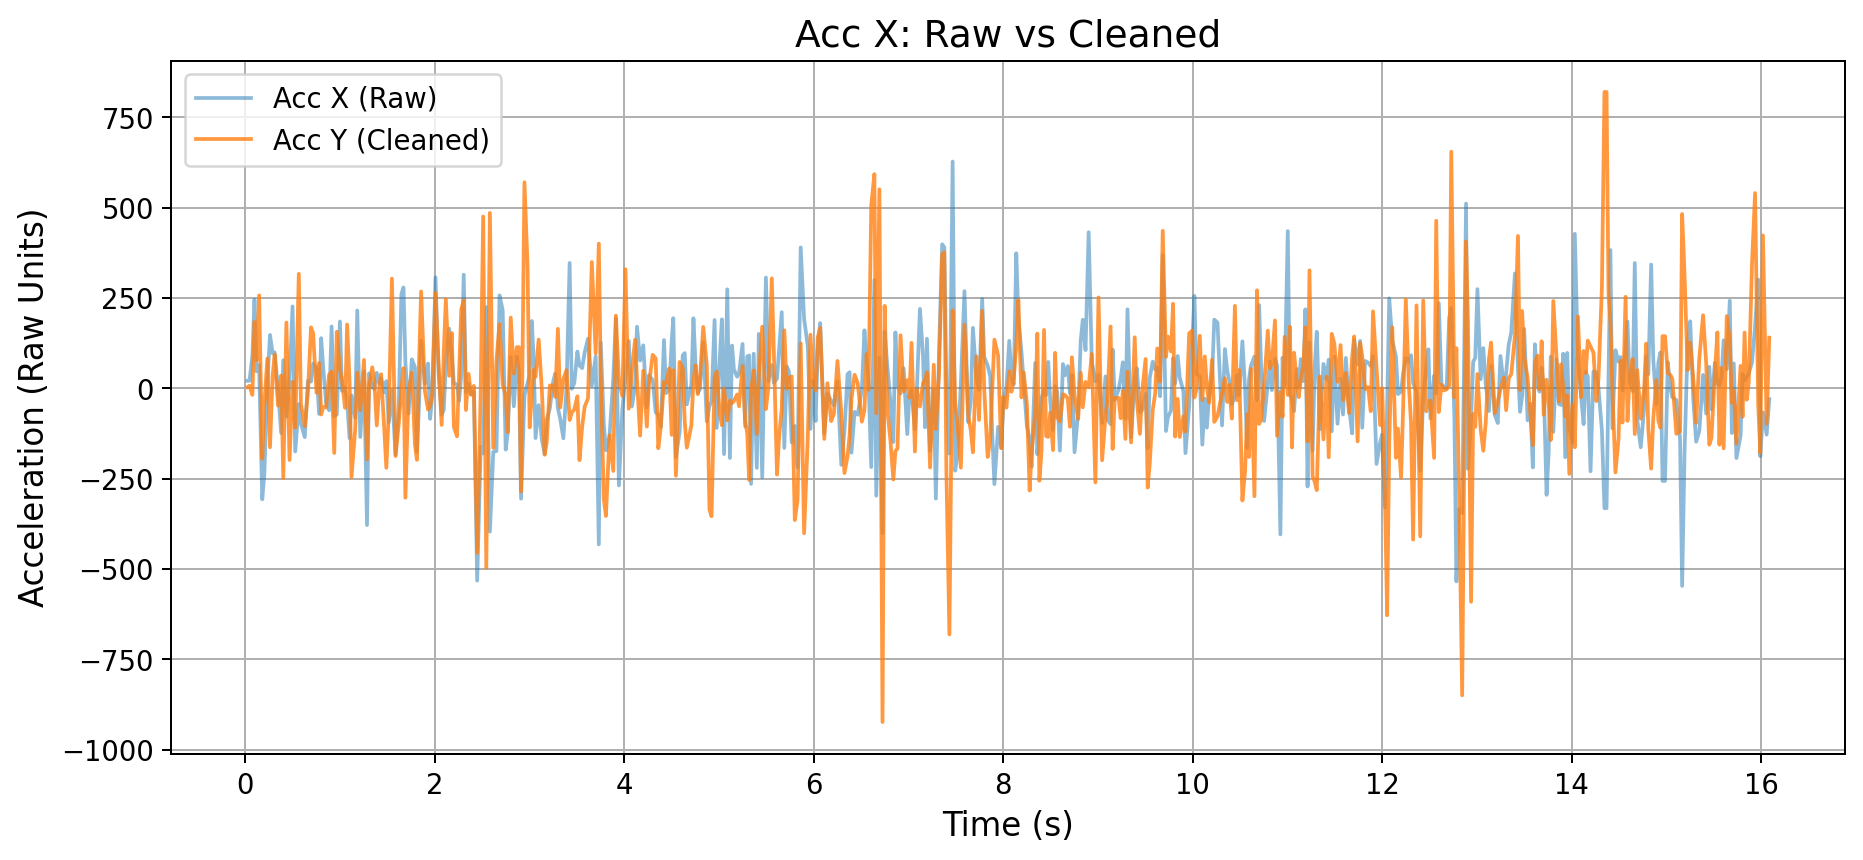

In [295]:
plt.plot(times_sec, acc_x_values, label='Acc X (Raw)', alpha=0.5)
plt.plot(times_sec, acc_y_clean, label='Acc Y (Cleaned)', alpha=0.8)
plt.legend()
plt.title("Acc X: Raw vs Cleaned")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (Raw Units)")
plt.grid(True)

plt.show()

# Read Out Distance

In [650]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 核心方法：将传感器原始数据转为全局 XY 坐标
# ==========================================
def get_global_coords(yaw_values, tof_values, robot_x, robot_y, angle_offset=0.0):
    """
    yaw_values: 原始陀螺仪角度数组
    tof_values: 原始 ToF 距离数组 (mm)
    robot_x, robot_y: 机器人当前所在的全局坐标 (feet)
    angle_offset: 传感器的安装朝向偏移 (ToF2=0度, ToF1=270度)
    """
    # 1. 解包并对齐连续航向角
    yaw_unwrapped = np.degrees(np.unwrap(np.radians(yaw_values)))
    yaw_continuous = yaw_unwrapped - yaw_unwrapped[0]

    # 2. 提取有效数据并转成英尺 (1 foot = 304 mm)
    valid_mask = (tof_values > 0) & (tof_values < 6000)
    valid_yaw = yaw_continuous[valid_mask]
    valid_dist_ft = tof_values[valid_mask] / 304.0

    # 3. 加上传感器的物理安装角度偏移
    angles_rad = np.radians(valid_yaw + angle_offset)

    # 4. 局部极坐标 -> 全局笛卡尔坐标
    # 0度是+Y轴，且逆时针角度增加 -> X = -sin(theta), Y = cos(theta)
    x_global = robot_x + valid_dist_ft * np.sin(-angles_rad)
    y_global = robot_y + valid_dist_ft * np.cos(angles_rad)

    return x_global, y_global

# ==========================================
# 准备数据与画布
# ==========================================

# 你的 5 个测绘站立点
locations = [(0,0), (5,-3), (5,3), (-3,-2), (0,3)]
# 为每个测绘点分配一种颜色，方便在图上看出哪一面墙是哪个点扫出来的
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# 加载数据 (假设你的 npz 文件里保存了 'yaw_values', 'tof_1_values', 'tof_2_values' 这几个 array)
# 如果你保存时的变量名不一样，请在下方 for 循环中修改字符串 key！
datasets = [
    np.load("lab9/map_0_0.npz"),
    np.load("lab9/map_5_-3_1080_5.npz"),
    np.load("lab9/map_5_3_1080.npz"),
    np.load("lab9/map_-3_-2.npz"),
    np.load("lab9/map_0_3.npz")
]


In [761]:
ground_truth_lines = [
    [(-5.9,0.6), (-5.9, -4.7)], 
    [(-5.9,0.6), (-2.2, 0.6)],
    [(-2.2,4.8), (-2.2, 0.6)],
    [(-2.2,4.8), (6.8, 4.5)],
    [(6.8,4.5), (6.4, -4.3)],
    [(0.3,-4.3), (6.4, -4.3)],
    [(0.3,-4.3), (0.3, -2.5)],
    [(-0.7, -2.5), (0.3, -2.5)],
    [(-0.7, -2.5), (-0.8, -4.5)],
    [(-5.9, -4.7), (-0.8, -4.5)],
    [(2.7,1.6), (4.8, 1.6)],  #内部墙
    [(2.7,1.6), (2.7, -0.5)],
    [(2.7, -0.5), (4.8, -0.5)],
    [(4.8, -0.5), (4.8, 1.6)]
]

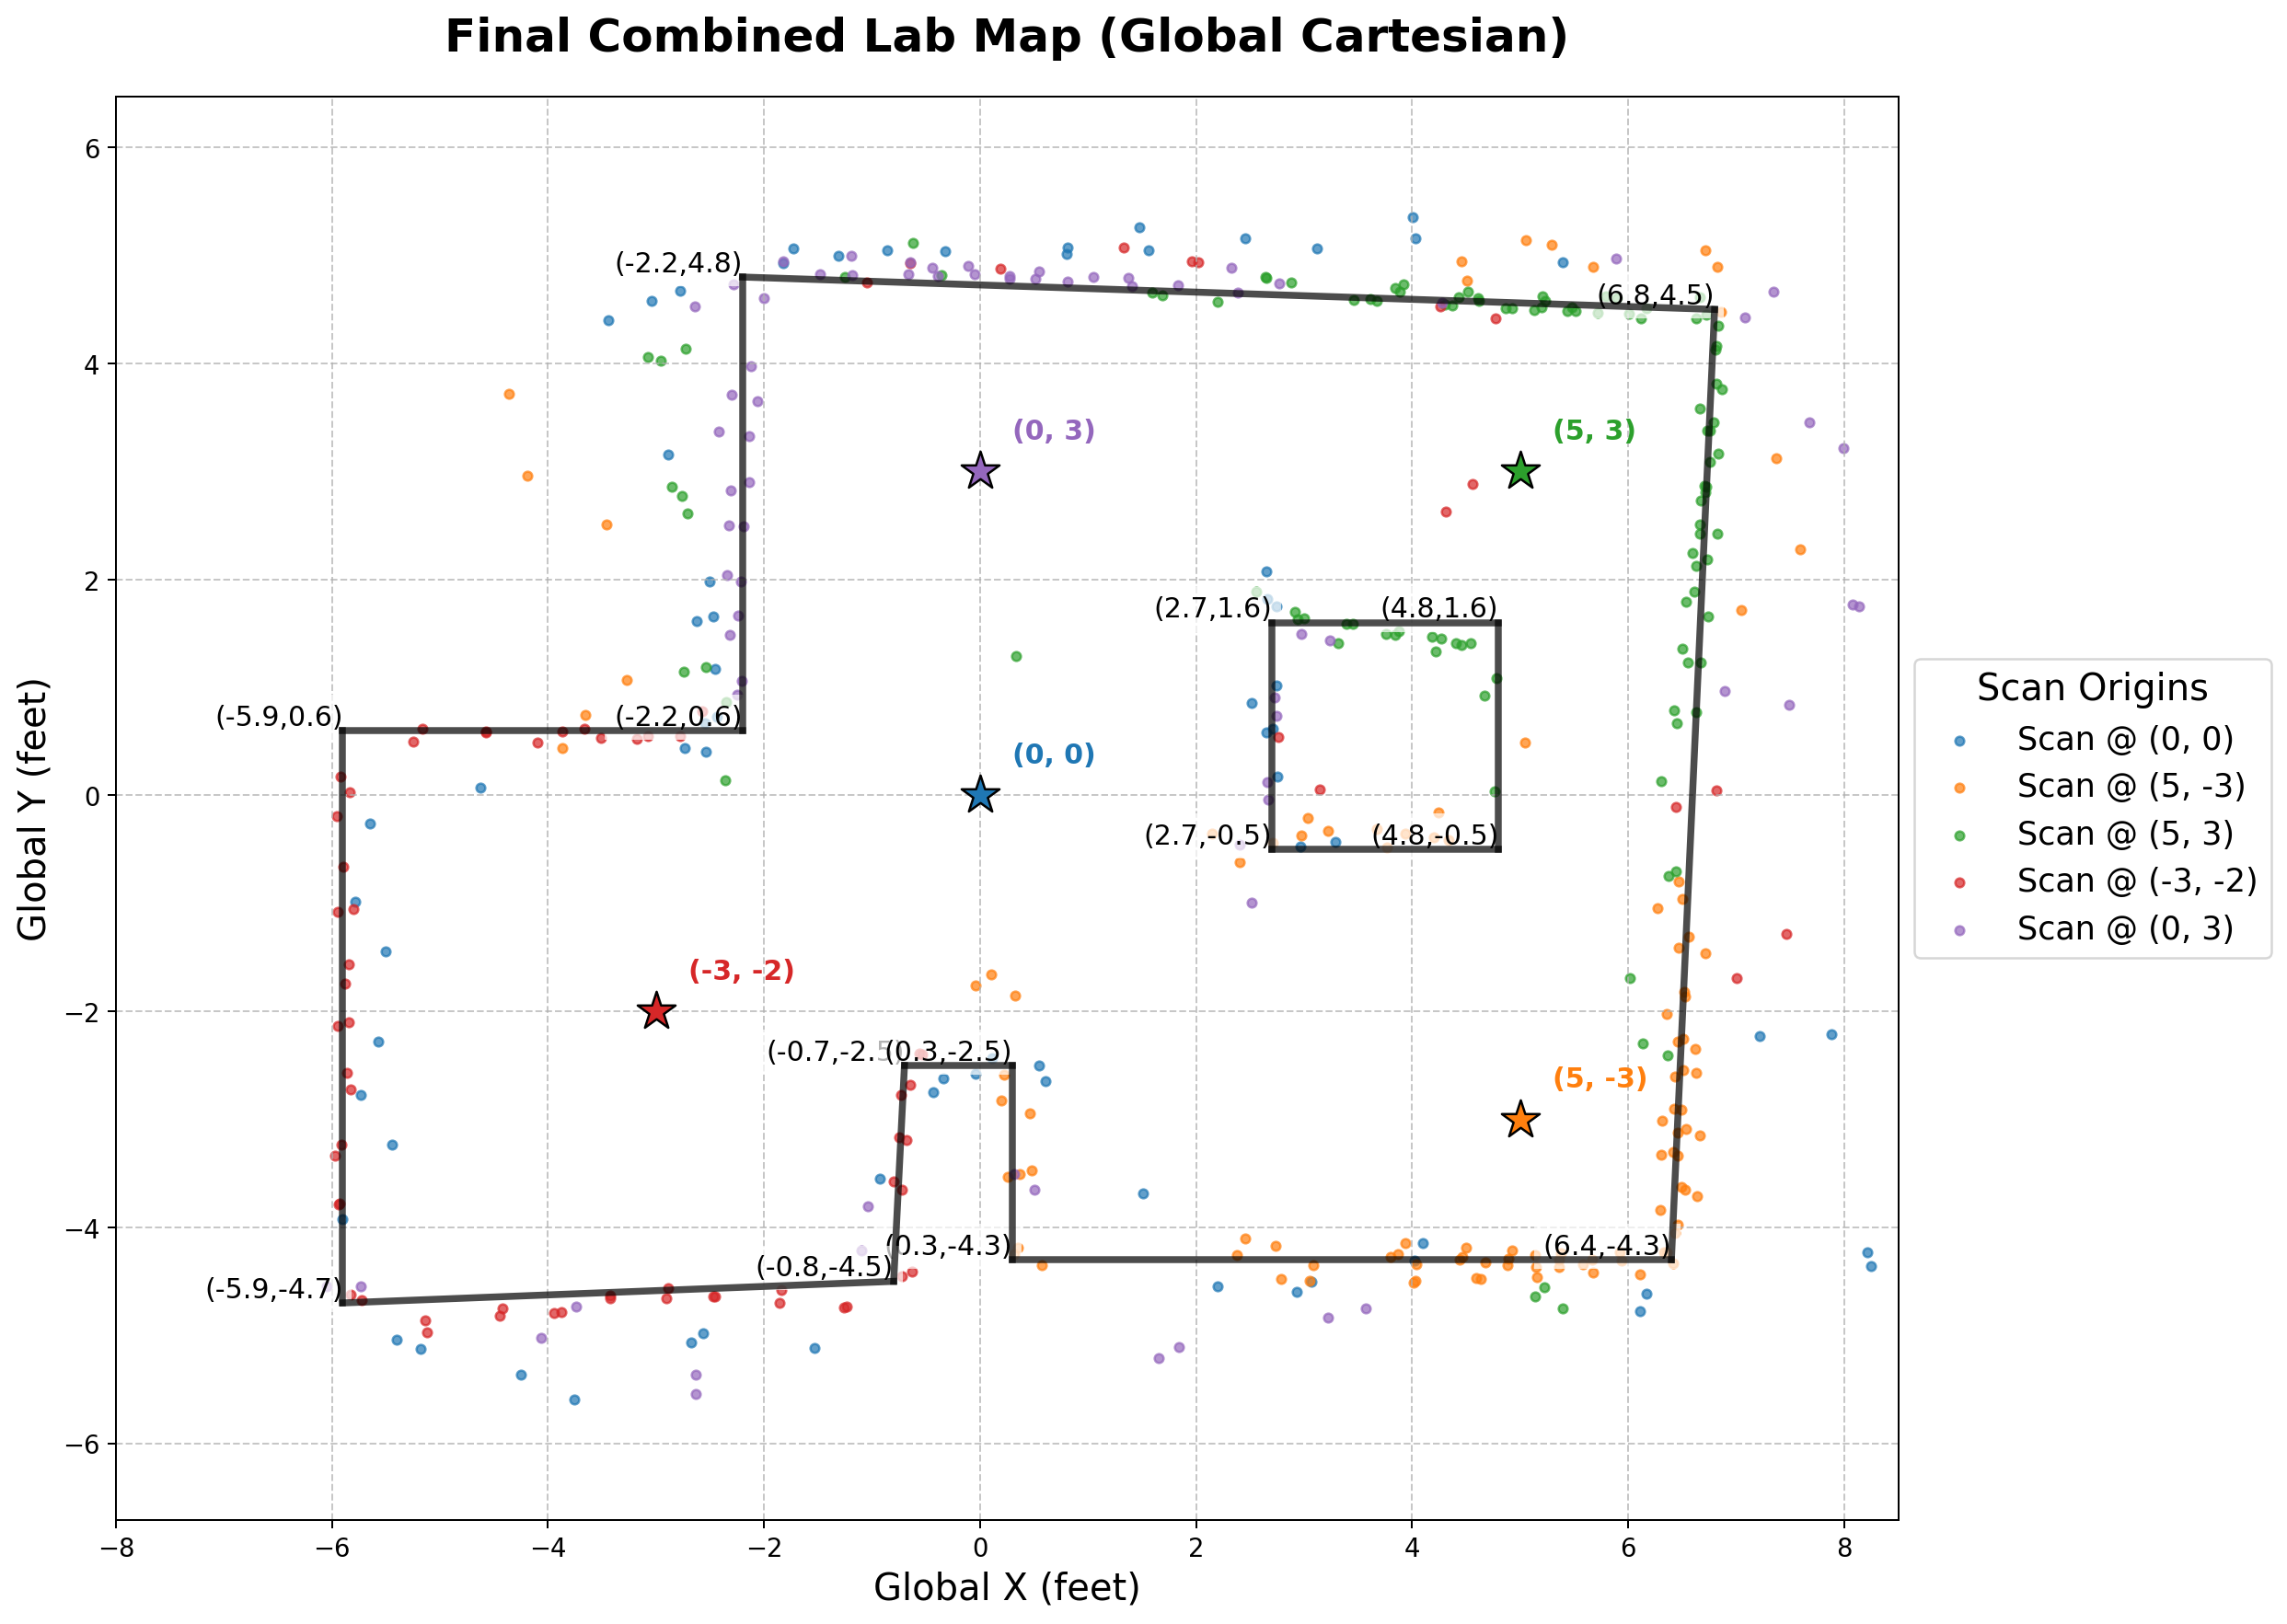

In [762]:
# ==========================================
# 遍历每个站立点，计算坐标并画图
# ==========================================
plt.figure(figsize=(14, 10))
for i, (loc, data) in enumerate(zip(locations, datasets)):
    robot_x, robot_y = loc
    color = colors[i]
    
    # 提取 npz 里面的数组
    # 【注意】请确保 "yaw_values" 等 key 和你使用 np.savez() 时指定的名称一致
    yaw = data['yaw_values']
    tof1 = data['tof_1_values']
    tof2 = data['tof_2_values']
    tof1 = np.where(tof1 == -1, 0, tof1 + 31.75)
    tof2 = np.where(tof2 == -1, 0, tof2 + 69.85)
    
    # 获取 ToF 2 (正前方, 偏移=0) 的全局坐标
    x2, y2 = get_global_coords(yaw, tof2, robot_x, robot_y, angle_offset=0.0)
    
    # 获取 ToF 1 (侧方, 偏移=270) 的全局坐标
    x1, y1 = get_global_coords(yaw, tof1, robot_x, robot_y, angle_offset=270.0)
    
    # 画出点云 (s=15 是点的大小，alpha=0.7 让重叠的墙壁边缘更柔和)
    plt.scatter(x2, y2, s=15, color=color, alpha=0.7, label=f'Scan @ {loc}')
    plt.scatter(x1, y1, s=15, color=color, alpha=0.7)
    
    # 画出机器人的站立点 (用巨大的星星表示)
    plt.scatter(robot_x, robot_y, marker='*', s=300, color=color, edgecolors='black', zorder=5)
    # 在星星旁边标上文字坐标
    plt.text(robot_x + 0.3, robot_y + 0.3, f'({robot_x}, {robot_y})', 
             fontsize=12, fontweight='bold', color=color)


# ==========================================
# ✨ 新增：定义你要画的线段列表 (List of Lines)
# 格式: [ [(起点X, 起点Y), (终点X, 终点Y)], ... ]
# 这里我随便写了一个闭合的房间边框和一堵内部墙作为示例，请替换为你实验室真实的坐标！
# ==========================================
# ground_truth_lines = [
#     [(-5.6,0.4), (-5.6, -4.5)], 
#     [(-5.6,0.4), (-2, 0.4)],
#     [(-2,4.5), (-2, 0.4)],
#     [(-2,4.5), (6.5, 4.5)],
#     [(6.5,4.5), (6.5, -4.2)],
#     [(0.5,-4.2), (6.5, -4.2)],
#     [(0.5,-4.2), (0.5, -2.5)],
#     [(-0.6, -2.5), (0.5, -2.5)],
#     [(-0.6, -2.5), (-0.6, -4.5)],
#     [(-5.6, -4.5), (-0.6, -4.5)],
#     [(2.6,1.7), (4.8, 1.7)],  #内部墙
#     [(2.6,1.7), (2.6, -0.5)],
#     [(2.6, -0.5), (4.8, -0.5)],
#     [(4.8, -0.5), (4.8, 1.7)]
# ]

# 将这些线段画到图上
for line in ground_truth_lines:
    (x1, y1), (x2, y2) = line
    # zorder=10 确保实线画在散点图的最上层，不会被点云遮挡
    plt.plot([x1, x2], [y1, y2], color='black', alpha=0.7, linewidth=3, linestyle='-', zorder=10)

# 收集所有顶点
vertices = set()

for line in ground_truth_lines:
    (x1, y1), (x2, y2) = line
    vertices.add((x1, y1))
    vertices.add((x2, y2))

# 统一画顶点
for (x, y) in vertices:
    plt.text(x, y,
             f'({x:.1f},{y:.1f})',
             fontsize=12,
             ha='right',
             va='bottom',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
# ==========================================
# 图表美化
# ==========================================
plt.title('Final Combined Lab Map (Global Cartesian)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Global X (feet)', fontsize=16)
plt.ylabel('Global Y (feet)', fontsize=16)
plt.axis('equal') # 关键！保持长宽比一致，墙壁才不会被拉伸
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-8, 8.5)

# 把图例放到图外，防止挡住地图
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14, title="Scan Origins", title_fontsize=16)

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (3786611303.py, line 1)

In [686]:
pip install numpy pygame pyqt6 pyqtgraph pyyaml ipywidgets colorama

520055.76s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 14.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 11.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 MB 24.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 41.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
